In [1]:
import sys, os

os.environ.pop("PYTHONPATH", None)
os.environ.pop("PYTHONHOME", None)

sys.path = [
    p for p in sys.path
    if "/mnt/modules/easybuild" not in p
]

import typing_extensions
print(typing_extensions.__file__)

sys.path.insert(
    0,
    "/data/groups/vib.ai/stein.aerts/gpartel/software/deepSCENIC-dev/src"
)

/data/groups/vib.ai/stein.aerts/gpartel/software/miniconda3/envs/deepSCENIC/lib/python3.11/site-packages/typing_extensions.py


# Tutorial 3: Model Diagnosis

After training a deepSCENIC model, the critical question is: **did the model learn biologically meaningful regulatory patterns?**

This tutorial covers how to extract and visualize the model's learned representations to assess whether it has captured cell-type-specific gene regulation. We focus on two key embedding spaces:

1. **Enhancer activity (enh_act)**: Tests whether the tf2r matrix learned meaningful TF→region binding patterns
2. **Predicted gene regulatory signal (z_rna)**: Tests the full GRN pipeline (tf2r + r2g)

If cells cluster by type in these spaces, the model has learned to distinguish cell types based on their regulatory programs.

## Setup

First, let's import the required packages. deepSCENIC provides the {func}`~deepscenic.pl.embedding_umap` function to easily visualize embeddings stored in `mdata.obsm`.

In [2]:
import torch

import deepscenic as ds

print(f"deepSCENIC version: {ds.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

deepSCENIC version: 0.1.0
Using device: cuda


## Load Model and Data

We load the preprocessed MuData from {doc}`01_data_preparation` and the trained model from {doc}`02_training`. Make sure your MuData includes cell annotations (like cell type or cell state) that you can use to color the UMAP plots.

In [3]:
import os

# data_dir = "./data/MM_lines/"
data_dir = "/data/groups/vib.ai/stein.aerts/gpartel/data/MM_lines_demo/"
assert os.path.exists(data_dir), "Data directory not found"

# Load preprocessed MuData
mdata = ds.read(data_dir + "preprocessed_data.h5mu")

# Load trained model
model = ds.tl.load_model(data_dir + "checkpoints/deepscenic_model.pt", device=device)

# Verify cell annotations are available (if you have them)
print(f"\nCell annotations: {list(mdata.obs.columns)}")
if "cell_state" in mdata.obs:
    print(f"Cell states: {mdata.obs['cell_state'].value_counts().to_dict()}")

deepscenic.io - INFO - Loaded /data/groups/vib.ai/stein.aerts/gpartel/data/MM_lines_demo/preprocessed_data.h5mu: 936 cells, 12109 genes, 288643 regions
2026-08-12 14:28:38.372429: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-12 14:28:38.381484: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786537718.391014 2972354 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786537718.393736 2972354 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been re


Cell annotations: ['cell_line', 'cell_state', 'split']
Cell states: {'INT': 358, 'MEL': 318, 'MES': 260}


## Extract Model Embeddings

The deepSCENIC model produces several intermediate representations as it transforms TF expression into gene expression predictions:

| Embedding | Shape | What it tests |
|-----------|-------|---------------|
| **z_tf** | (n_cells, n_tfs) | Encoder only - latent TF expression |
| **enh_act** | (n_cells, n_regions) | Encoder + tf2r - enhancer activity from TF binding |
| **z_rna** | (n_cells, n_genes) | Full GRN (tf2r + r2g) - gene regulatory signal |
| **rna_rec** | (n_cells, n_genes) | Full model - reconstructed gene expression |
| **atac_rec** | (n_cells, n_regions) | Full model - reconstructed chromatin accessibility |

### Which Embeddings Matter for Diagnosis?

The key diagnostic embeddings are **enh_act** and **z_rna** because they test whether the learned GRN matrices (tf2r and r2g) capture biology:

- **enh_act = z_tf @ tf2r.T**: If enhancer activity clusters by cell type, the tf2r matrix learned cell-type-specific TF→region binding
- **z_rna = enh_act @ r2g**: If predicted gene signal clusters by cell type, the full GRN pipeline works

The {func}`~deepscenic.tl.to_latent` function extracts all embeddings and stores them in `mdata.obsm` with the prefix `X_deepscenic_`.

In [4]:
# Extract all embeddings in one pass and store in mdata.obsm
# Use batch_size to avoid GPU memory issues
ds.tl.to_latent(model, mdata, batch_size=128)

# Embeddings are now stored in mdata.obsm with X_deepscenic_ prefix
print("Extracted embeddings (stored in mdata.obsm):")
for key in mdata.obsm.keys():
    if key.startswith("X_deepscenic_"):
        print(f"  {key}: {mdata.obsm[key].shape}")

Extracting embeddings:   0%|          | 0/8 [00:00<?, ?it/s]

Extracted embeddings (stored in mdata.obsm):
  X_deepscenic_z_tf: (936, 1446)
  X_deepscenic_enh_act: (936, 288552)
  X_deepscenic_z_rna: (936, 12109)
  X_deepscenic_rna_rec: (936, 12109)
  X_deepscenic_atac_rec: (936, 288552)


## Visualizing Enhancer Activity and Predicted Gene Signal

The **enhancer activity (enh_act)** embedding is the primary diagnostic. It shows whether the model learned cell-type-specific enhancer regulation through TF binding (the tf2r matrix).

The **predicted gene regulatory signal (z_rna)** tests the full GRN pipeline. It's computed as enh_act @ r2g, so good clustering here means both tf2r and r2g matrices are working together to predict cell-type-specific gene regulation.

### What to Expect

For a well-trained model on the MM_lines dataset, you should see:
- **MEL (melanocytic)** and **MES (mesenchymal)** cells forming distinct clusters
- **INT (intermediate)** cells positioned between them
- Clear separation by cell state, driven by different enhancer activity/gene signal profiles

The {func}`~deepscenic.pl.embedding_umap` function handles PCA and UMAP computation internally:

Let's visualize both key embeddings side-by-side:

/data/groups/vib.ai/stein.aerts/gpartel/software/miniconda3/envs/deepSCENIC/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/data/groups/vib.ai/stein.aerts/gpartel/software/miniconda3/envs/deepSCENIC/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


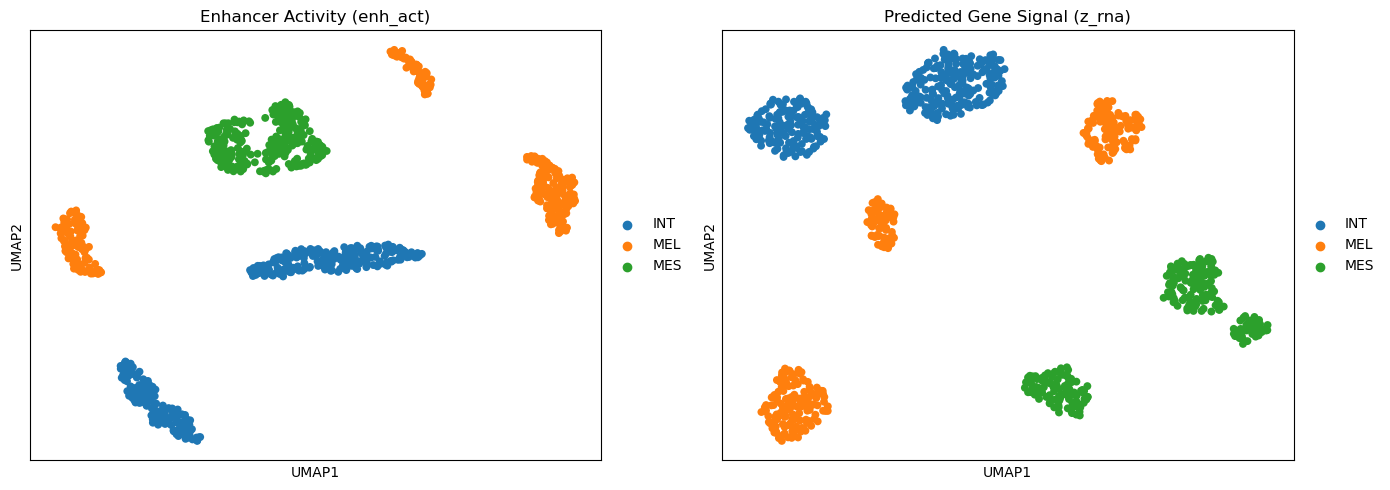

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ds.pl.embedding_umap(
    mdata, key="X_deepscenic_enh_act", color="cell_state", ax=axes[0], title="Enhancer Activity (enh_act)"
)
ds.pl.embedding_umap(
    mdata, key="X_deepscenic_z_rna", color="cell_state", ax=axes[1], title="Predicted Gene Signal (z_rna)"
)

plt.tight_layout()
plt.show()

## Training Curves

If you trained the model yourself using `ds.tl.train()` (rather than loading a converted legacy model), you can examine the training history to assess convergence. Usually, you would have tracked these during training (e.g. using tensorboard), but we store them in the model file too soo you can review them later. 

```python
# Plot training curves (only available for models trained with ds.tl.train())
ds.pl.loss_curves(model)
```

```{note}
Legacy models loaded with `ds.tl.load_legacy_model()` don't have training history, so this function won't work for them.
```

## TF Activity Profiles by Cell Type

Once you've confirmed good clustering in enh_act and z_rna, you can dive deeper into which TFs drive the cell-type differences. A clustered heatmap of TF activity scores reveals the regulatory programs that distinguish each cell type.

### Computing TF Activity Scores

The TF activity score for each cell type is computed by:
1. Identifying **differentially** active enhancers per cell type (Wilcoxon rank-sum test)
2. Weighting TF activity by their binding to these active enhancers (via the tf2r matrix)

This gives a biologically meaningful measure of how important each TF is for each cell type's regulatory program.

In [27]:
# Compute TF activity scores for visualization
active_enh = ds.tl.identify_active_enhancers(model, mdata, class_key="cell_state")
tf_scores = ds.tl.compute_tf_activity_scores(
    model, mdata, class_key="cell_state", active_enhancers=active_enh, zscore=True
)

deepscenic.tl._grn - INFO - Cell type 'MEL': 3000 active enhancers
deepscenic.tl._grn - INFO - Cell type 'MES': 3000 active enhancers
deepscenic.tl._grn - INFO - Cell type 'INT': 3000 active enhancers


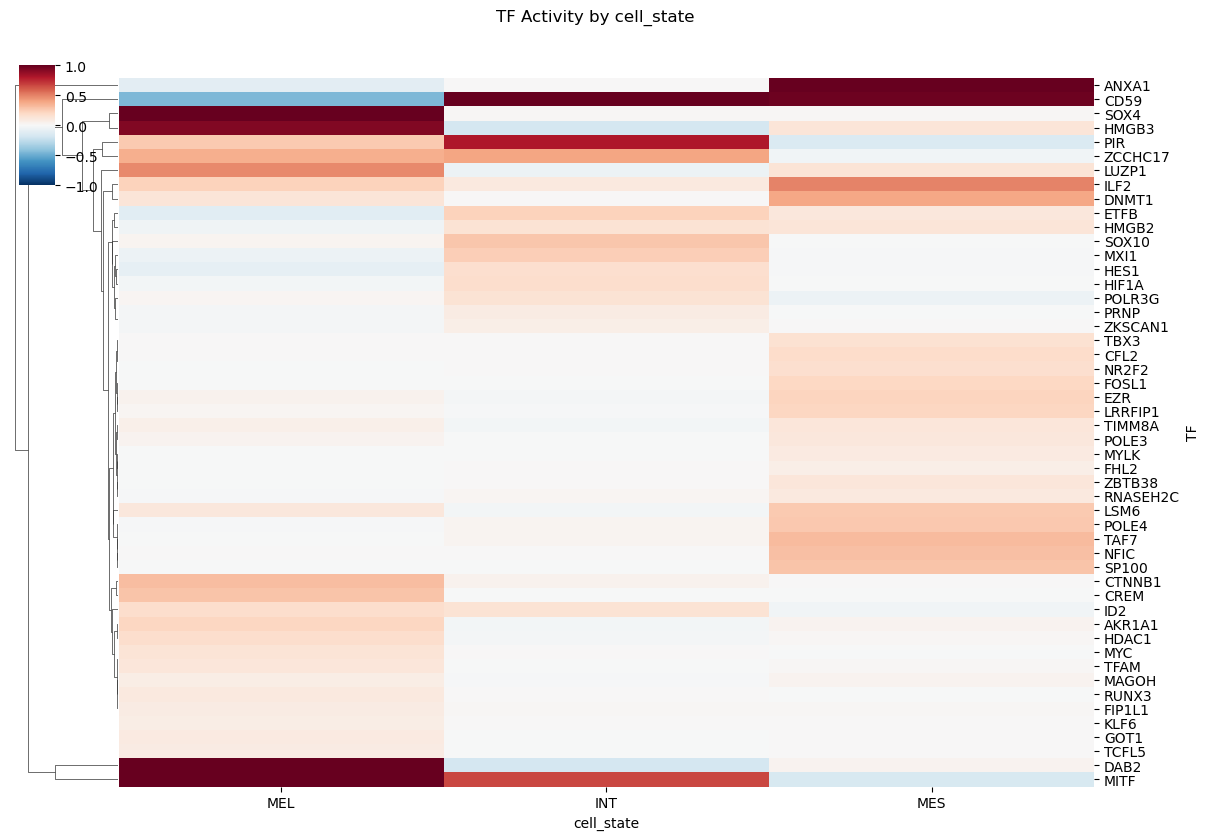

In [28]:
# Show top 50 most variable TFs across cell states
ds.pl.tf_activity_clustermap(tf_scores.loc[:, ['MEL', 'INT', 'MES']], xlabel="cell_state", top_n_tfs=50, vmax=1, vmin=-1)

In the heatmap above, each row is a TF and each column is a cell type/state. TFs are clustered by their activity patterns, so TFs with similar cell-type-specificity appear together. Look for:

- **Cell-type-specific TFs**: TFs that are differentially active in one cell state but not others
- **Known biology**: For melanoma, you might expect MITF-family TFs to be active in MEL cells, and AP-1/inflammatory TFs in MES cells

This analysis is explored in more detail in {doc}`04_grn_analysis`.